# Import Libraries

In [1]:
import os
import sys

#PyTorch
import torch as torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
import time 
from torchinfo import summary

import pandas as pd
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import random
from typing import Iterable, Callable


#sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Import torchvision
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchinfo import summary

#Import tqdm for a cool progress bar
from tqdm.auto import tqdm

# Measure time
from timeit import default_timer as timer

print(f"PyTorch Version: {torch.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"SciPy Version: {scipy.__version__}")

PyTorch Version: 2.2.2
Numpy Version: 1.26.4
Pandas Version: 3.0.0
Matplotlib Version: 3.10.8
SciPy Version: 1.17.0


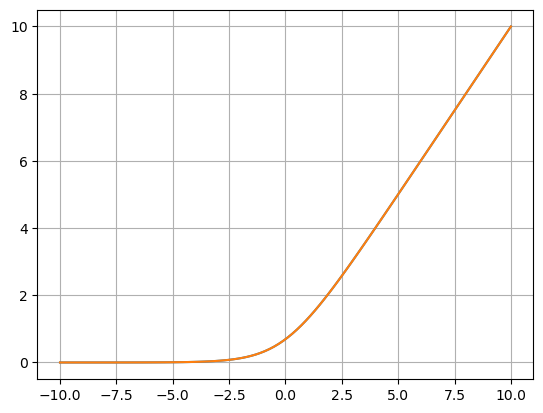

In [21]:
x = np.linspace(-10, 10, 100)
x = torch.tensor(x, dtype=torch.float32)    
plt.plot(x, torch.nn.functional.softplus(x))
plt.plot(x, torch.log(torch.tensor(1) + torch.exp(x)))
plt.grid(True)
plt.show()

In [18]:
torch.log(torch.exp(torch.tensor(1))).numpy().item()

1.0

# MP GELU

* Modified Parametric Gaussian Error Linear Unit 
$$
f(x) = \frac{x}{2} \left[ 1 + \text{erf}\left( \frac{\lambda x}{\sqrt{2}}\right)\right] = \frac{x}{2} + \frac{x}{\sqrt{\pi}}\int_{0}^{\lambda x / \sqrt{2}} e^{-u^{2}}du
$$
where $\lambda  = (1 + \ln(1 + e^{s})) \geq 1$   $\forall s \in \mathbb{R}$

In [32]:
class MPGELU(torch.nn.Module):
    '''
    Modified Parametric Gaussian Error Linear Unit (MPGELU) Activation Function
    '''
    def __init__(self,initial_s: float = 0.0, use_softplus: bool = True):
        super(MPGELU, self).__init__()
        self.initial_s = torch.nn.Parameter(torch.tensor(initial_s, dtype=torch.float32))
        self.use_softplus = use_softplus

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_softplus:
            lam = 1.0 + torch.nn.functional.softplus(self.initial_s)
        else:
            lam = 1.0 + torch.log(torch.tensor(1.0, device=x.device) + torch.exp(self.initial_s))
        output = torch.mul(0.5 * x, (1.0 + torch.erf(torch.mul(lam,x)/ (np.sqrt(2)))))
        return output



## Plot

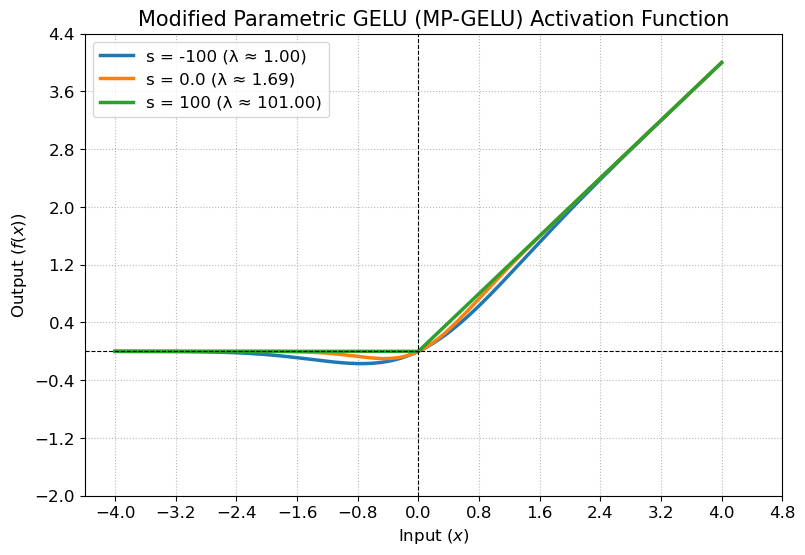

In [72]:
x_np = np.linspace(-4.0, 4.0, 400)
x_tensor = torch.tensor(x_np, dtype=torch.float32)
# s_values = np.arange(-2.0, 2.0, 0.1)
s_values = [-100, 0.0, 100, ]
plt.figure(figsize=(9, 6))

for s_val in s_values:
    activation1 = MPGELU(initial_s=s_val)
    activation2 = MPGELU(initial_s=s_val, use_softplus=False)
    with torch.no_grad():
        y_tensor1 = activation1(x_tensor)
        y_tensor2 = activation2(x_tensor)

    lam_val = (1.0 + F.softplus(torch.tensor(s_val, dtype=torch.float32))).item()
    plt.plot(x_np, y_tensor1.numpy(), label=f"s = {s_val} (λ ≈ {lam_val:.2f})", linewidth=2.5)
    # plt.plot(x_np, y_tensor2.numpy(), label=f"s = {s_val} (λ ≈ {lam_val:.2f})", linewidth=2)

# 4. Format the plot
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Modified Parametric GELU (MP-GELU) Activation Function", fontsize=15)
xticks = np.arange(-4, 5, 0.8)
plt.xticks(xticks,fontsize=12)
plt.xlabel("Input ($x$)", fontsize=12)
yticks = np.arange(-2, 5, 0.8)
plt.yticks(yticks,fontsize=12)
plt.ylabel("Output ($f(x)$)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.9)
plt.legend(fontsize=12)
plt.show()